<a href="https://colab.research.google.com/github/AlejoCNYT/econometrics-notebooks/blob/main/LinearRegression-Training_Exercise_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== RESULTADOS INCISO (A) ===
Intercepto (a): 10.3860
Pendiente (b):  -0.0380
R-cuadrado:     0.6734
Error (s):      0.1228
------------------------------
=== RESULTADOS INCISO (C) ===
Año 2008 (G=16):
  - Predicción: 9.778s
  - Tiempo Real: 9.69s
  - Error: -0.088s
Año 2012 (G=17):
  - Predicción: 9.740s
  - Tiempo Real: 9.63s
  - Error: -0.110s
Año 2016 (G=18):
  - Predicción: 9.702s
  - Tiempo Real: 9.81s
  - Error: 0.108s
------------------------------


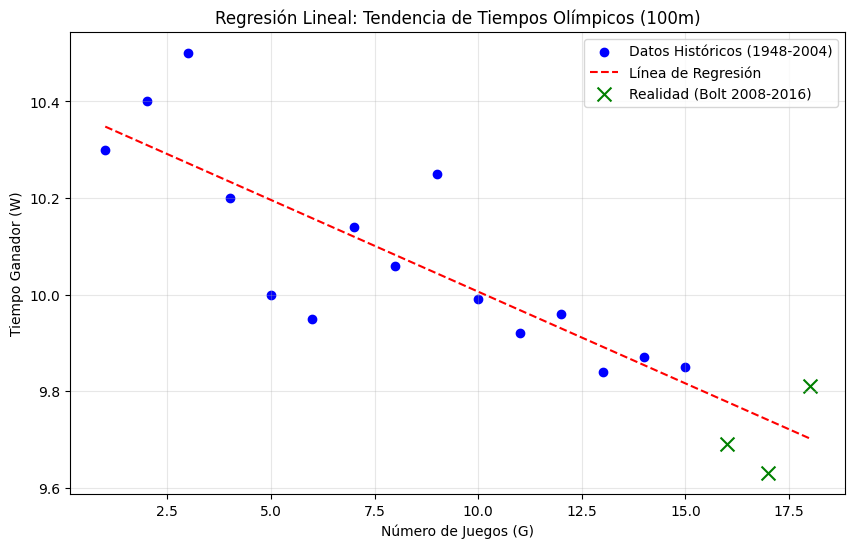

In [4]:
# =================================================================
# MOOC Econometrics - Training Exercise 1.3
# Análisis de los 100m planos (1948 - 2004)
# =================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. PREPARACIÓN DE DATOS
# G = Número del juego (1 a 15)
# W = Tiempo ganador en segundos
data = {
    'G': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'W': [10.30, 10.40, 10.50, 10.20, 10.00, 9.95, 10.14, 10.06, 10.25, 9.99, 9.92, 9.96, 9.84, 9.87, 9.85]
}

df = pd.DataFrame(data)

# 2. ESTIMACIÓN DEL MODELO (Inciso A)
# Modelo: W = a + b*G + epsilon
X = df['G']
y = df['W']

# Añadimos la constante para obtener el intercepto (a)
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

# Extraer métricas
a = model.params.iloc[0]      # Intercepto con .iloc
b = model.params.iloc[1]      # Pendiente con .iloc
r2 = model.rsquared      # R-cuadrado
s = np.sqrt(model.mse_resid) # Error estándar de la regresión

print("=== RESULTADOS INCISO (A) ===")
print(f"Intercepto (a): {a:.4f}")
print(f"Pendiente (b):  {b:.4f}")
print(f"R-cuadrado:     {r2:.4f}")
print(f"Error (s):      {s:.4f}")
print("-" * 30)

# 3. PREDICCIONES (Inciso C)
# 2008 -> G=16, 2012 -> G=17, 2016 -> G=18
años_futuros = [2008, 2012, 2016]
juegos_futuros = np.array([16, 17, 18])
tiempos_reales = [9.69, 9.63, 9.81] # Datos reales (Usain Bolt)

predicciones = a + b * juegos_futuros

print("=== RESULTADOS INCISO (C) ===")
for año, g, pred, real in zip(años_futuros, juegos_futuros, predicciones, tiempos_reales):
    print(f"Año {año} (G={g}):")
    print(f"  - Predicción: {pred:.3f}s")
    print(f"  - Tiempo Real: {real}s")
    print(f"  - Error: {real - pred:.3f}s")
print("-" * 30)

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 6))

# Datos históricos
plt.scatter(df['G'], df['W'], color='blue', label='Datos Históricos (1948-2004)')

# Línea de regresión
x_range = np.linspace(1, 18, 100)
y_range = a + b * x_range
plt.plot(x_range, y_range, color='red', linestyle='--', label='Línea de Regresión')

# Predicciones vs Realidad
plt.scatter(juegos_futuros, tiempos_reales, color='green', marker='x', s=100, label='Realidad (Bolt 2008-2016)')

plt.title('Regresión Lineal: Tendencia de Tiempos Olímpicos (100m)')
plt.xlabel('Número de Juegos (G)')
plt.ylabel('Tiempo Ganador (W)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()